In [24]:
import requests, os, json
# API_KEY를 .env 파일 내 환경변수로 관리하고 python-dotenv 패키지로 사용
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv('API_KEY')

# url의 parameter로 사용할 연도, 월을 리스트로 작성하는 함수
def get_year_months():
    year_months = []
    for year in range(2015, 2024+1):
        for month in range(1, 12+1):
            year_months.append(f"{year}/{month:02d}")
    return year_months

# 최종결과가 저장될 리스트 변수 선언
responses = []

# 월별 반복문
for year_month in get_year_months():
    
    # url 설정. END_INDEX는 회원이 7유형(개인(일반), 소상공인, 기업·법인, 아파트, 공공기관, 학교, 종교단체)으로 분류되어 있으므로 7로 설정
    url = f"http://openapi.seoul.go.kr:8088/{api_key}/json/energyUseDataSummaryInfo/1/7/{year_month}"

    # 이 프로그램에서 데이터 추출은 pandas 패키지를 사용하지 않고 json 패키지로 개인 유형의 현년 전기, 가스, 수도, 지역난방 에너지 사용량 데이터만 추출함
    try:
        response = requests.get(url)
        response_to_jsons = response.json()
        rows = response_to_jsons["energyUseDataSummaryInfo"]["row"]
        personal_rows = [row for row in rows if row.get("MM_TYPE") == "개인"]
        year = personal_rows[0]['YEAR']         # 연도
        mon = personal_rows[0]['MON']           # 월
        mm_type = personal_rows[0]['MM_TYPE']   # 회원 유형
        eus = personal_rows[0]['EUS']           # 현년 전기 사용량
        gus = personal_rows[0]['GUS']           # 현년 가스 사용량
        wus = personal_rows[0]['WUS']           # 현년 수도 사용량        
        hus = personal_rows[0]['HUS']           # 현년 지역난방 사용량
        current_year_month_data = [year, mon, mm_type, eus, gus, wus, hus]
        responses.append(current_year_month_data)
    except requests.exceptions.RequestException as e:
        print(f"API 호출 실패: {e}")
    except json.JSONDecodeError as e:
        print(f"JSON 파싱 실패: {e}")

print("API 호출 및 JSON 파싱 성공")
print(responses)

API 호출 및 JSON 파싱 성공
[['2015', '01', '개인', '193784708', '59133720', '12819757.886', '22740838.937'], ['2015', '02', '개인', '189974230', '56487358', '12656888.218', '18793320.213'], ['2015', '03', '개인', '175215719', '49984873', '12655474.249', '13826348.508'], ['2015', '04', '개인', '183891769', '37306841', '12954773.246', '5836002.885'], ['2015', '05', '개인', '177289769', '22060892', '13086734.214', '1320895.801'], ['2015', '06', '개인', '186073153', '12677645', '14241651.402', '294312.634'], ['2015', '07', '개인', '165114568', '8893640', '12083879.038', '702863.645'], ['2015', '08', '개인', '242000479', '7619018', '15164553.742', '460288.965'], ['2015', '09', '개인', '207540868', '6518422', '14419078.727', '305710.728'], ['2015', '10', '개인', '186473958', '8924018', '14711828.766', '3167520.127'], ['2015', '11', '개인', '196892030', '20322557', '13692668.676', '11210982.51'], ['2015', '12', '개인', '203388142', '40095231', '13904162.958', '21102616.717'], ['2016', '01', '개인', '215330620', '57641741', '

In [40]:
import requests, os
import pandas as pd

from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv('API_KEY')

def get_year_months():
    year_months = []
    for year in range(2015, 2024+1):
        for month in range(1, 12+1):
            year_months.append(f"{year}/{month:02d}")
    return year_months

# Empty DataFrame 만들기
df = pd.DataFrame()

# 월별 반복문
for year_month in get_year_months():
    
    url = f"http://openapi.seoul.go.kr:8088/{api_key}/json/energyUseDataSummaryInfo/1/7/{year_month}"

    try:
        response = requests.get(url)
        response_to_jsons = response.json()
        rows = response_to_jsons["energyUseDataSummaryInfo"]["row"]
        monthly_df = pd.DataFrame(rows)                            # 월별 데이터를 DataFrame으로 만들기
        personal_df = monthly_df[monthly_df['MM_TYPE'] == "개인"]   # 회원유형 '개인'인 데이터 선택
        df = pd.concat([df, personal_df])                          # df에 personal_df 추가
        
    except requests.exceptions.RequestException as e:
        print(f"API 호출 실패: {e}")

df = df[['YEAR', 'MON', 'MM_TYPE', 'EUS', 'GUS', 'WUS', 'HUS']]
df = df.reset_index(drop=True)                                      # index 재설정
print(df)

     YEAR MON MM_TYPE        EUS       GUS           WUS           HUS
0    2015  01      개인  193784708  59133720  12819757.886  22740838.937
1    2015  02      개인  189974230  56487358  12656888.218  18793320.213
2    2015  03      개인  175215719  49984873  12655474.249  13826348.508
3    2015  04      개인  183891769  37306841  12954773.246   5836002.885
4    2015  05      개인  177289769  22060892  13086734.214   1320895.801
..    ...  ..     ...        ...       ...           ...           ...
115  2024  08      개인  463971328   7072251    15873544.6    130082.263
116  2024  09      개인  409872908   5729131    15143321.6   3420507.136
117  2024  10      개인  282268119   8233421    15297669.9   2695491.396
118  2024  11      개인  257927956  17418221    14678672.5   8836296.454
119  2024  12      개인  134828126  42103424     7326853.6   1513199.277

[120 rows x 7 columns]


In [41]:
# 월에 따라 계절을 반환하는 함수
def get_season(month):
    month = int(month)
    if month in [3,4,5]:
        return "봄"
    elif month in [6,7,8]:
        return "여름"
    elif month in [9,10,11]:
        return "가을"
    else:
        return "겨울"

# apply 메서드로 반환받은 계절을 DataFrame 열에 추가
df["SEASON"] = df["MON"].apply(get_season)
print(df)

     YEAR MON MM_TYPE        EUS       GUS           WUS           HUS SEASON
0    2015  01      개인  193784708  59133720  12819757.886  22740838.937     겨울
1    2015  02      개인  189974230  56487358  12656888.218  18793320.213     겨울
2    2015  03      개인  175215719  49984873  12655474.249  13826348.508      봄
3    2015  04      개인  183891769  37306841  12954773.246   5836002.885      봄
4    2015  05      개인  177289769  22060892  13086734.214   1320895.801      봄
..    ...  ..     ...        ...       ...           ...           ...    ...
115  2024  08      개인  463971328   7072251    15873544.6    130082.263     여름
116  2024  09      개인  409872908   5729131    15143321.6   3420507.136     가을
117  2024  10      개인  282268119   8233421    15297669.9   2695491.396     가을
118  2024  11      개인  257927956  17418221    14678672.5   8836296.454     가을
119  2024  12      개인  134828126  42103424     7326853.6   1513199.277     겨울

[120 rows x 8 columns]


In [5]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/dejavu
	/usr/share/fonts/truetype/nanum
/root/.local/share/fonts: skipping, no such directory
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/truetype/dejavu: caching, new cache contents: 6 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 33 fonts, 0 dirs
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/dejavu: skipping, looped directory detected

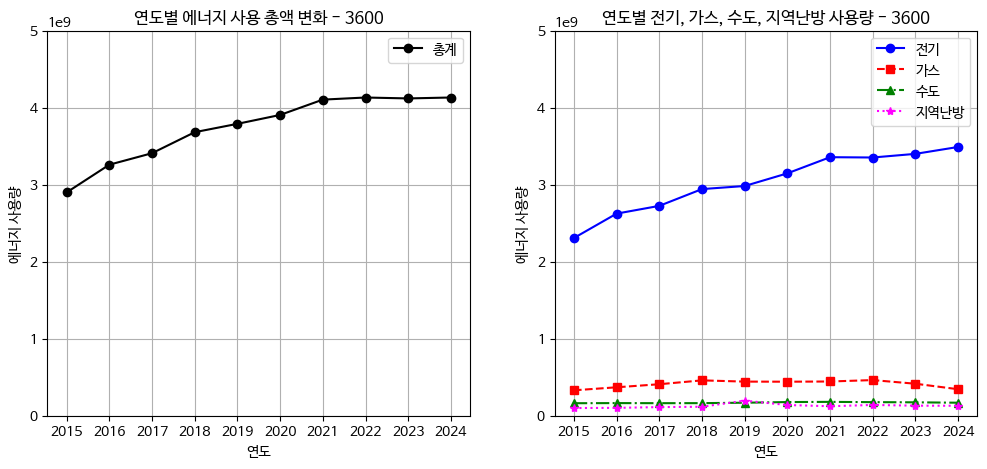

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 사용 설정
plt.rc('font', family='NanumBarunGothic')

# 숫자로 변환
cols = ["EUS", "GUS", "WUS", "HUS"]
df[cols] = df[cols].apply(pd.to_numeric)

# 연도별 데이터 정리
df_yearly = df.groupby("YEAR")[cols].sum().reset_index()
df_yearly["TOTAL"] = df_yearly[cols].sum(axis=1)

# 2개 서브플롯 생성 (1행 2열)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# 첫 번째 서브플롯 : 연도별 에너지 총 사용량 선 그래프
axes[0].plot(df_yearly.YEAR, df_yearly.TOTAL, marker='o', linestyle='-', color='black', label='총계')
axes[0].set_title("연도별 에너지 사용 총액 변화 - 3600")
axes[0].set_xlabel("연도")
axes[0].set_ylabel("에너지 사용량")
axes[0].set_ylim(0,5000000000)
axes[0].grid(True)
axes[0].legend()

# 두 번째 서브플롯 : 연도별 전기, 가스, 수도, 지역난방 사용량 선 그래프
axes[1].plot(df_yearly.YEAR, df_yearly.EUS, marker='o', linestyle='-', color='blue', label='전기')
axes[1].plot(df_yearly.YEAR, df_yearly.GUS, marker='s', linestyle='--', color='red', label='가스')
axes[1].plot(df_yearly.YEAR, df_yearly.WUS, marker='^', linestyle='-.', color='green', label='수도')
axes[1].plot(df_yearly.YEAR, df_yearly.HUS, marker='*', linestyle=':', color='magenta', label='지역난방')
axes[1].set_title("연도별 전기, 가스, 수도, 지역난방 사용량 - 3600")
axes[1].set_xlabel("연도")
axes[1].set_ylabel("에너지 사용량")
axes[1].set_ylim(0,5000000000)
axes[1].grid(True)
axes[1].legend()

plt.show()

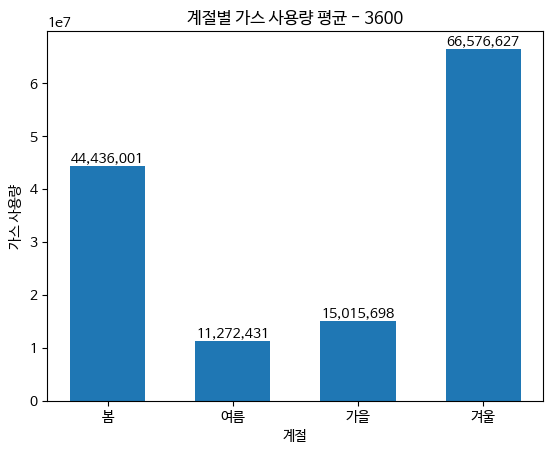

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# 가스 사용량을 숫자로 변환
df['GUS'] = df['GUS'].apply(pd.to_numeric)

# 계절별 데이터 정리
df_season = df.groupby('SEASON')['GUS'].mean().reset_index()

# SEASON 열을 '봄','여름','가을','겨울' 순으로 정렬
categories = ['봄', '여름', '가을', '겨울']
df_season['SEASON'] = pd.Categorical(df_season['SEASON'], categories=categories, ordered=True)
df_season = df_season.sort_values(by="SEASON")

# 막대 그래프 그리기
bars = plt.bar(df_season.SEASON, df_season.GUS, width=0.6)
plt.bar_label(bars, fmt='{:,.0f}', fontsize=10 )
plt.title("계절별 가스 사용량 평균 - 3600")
plt.xlabel("계절")
plt.ylabel("가스 사용량")
plt.show()